# Three-Qubit Quantum Energy Teleportation (QET) — Reproduction Notebook

Companion code for **"Three-Qubit Quantum Energy Teleportation Protocol for Significantly
High Energy Efficiency Utilizing Superconducting Qubits."**

This notebook reproduces, from scratch, every quantitative result in the paper:

1. The 3-qubit transverse-field Ising Hamiltonian, its entangled zero-energy ground state, and the closed-form coefficient $M$.
2. The zero-mean-energy constants $c_H,\,c_V$.
3. **MISO** protocol — two senders deposit a combined energy via an entangle-then-measure measurement; Bob extracts $\eta_{\mathrm{MISO}}=W/\langle E_{AC}\rangle \approx 52\text{–}60\%$ (energy-conserving).
4. **Assisted SISO** protocol — a single sender plus a zero-energy helper; $\eta=-(\langle H_2\rangle+\langle V_{0,2}\rangle)/E_0 \approx 45\text{–}55\%$.
5. The exact joint-receiver bound.
6. Comparison with the minimal 2-qubit model (work efficiency $\approx 11\%$).
7. Efficiency heatmaps over the $(h,k)$ plane.
8. Hardware-ready Qiskit circuits with shot-based readout of the energy components.

**Conventions.** Qubits $q_0=$ Alice, $q_1=$ Charlie, $q_2=$ Bob. All operators are exact
$8\times8$ matrices (statevector); the Qiskit section additionally samples the circuits on the
Aer simulator.

**Dependencies.** `numpy`, `matplotlib`, `qiskit`, `qiskit-aer`. The exact sections (1–7) need
only NumPy/Matplotlib; section 8 needs Qiskit.


## 0. Setup — operators and the ground state

In [1]:
import numpy as np
np.set_printoptions(precision=4, suppress=True)

I2 = np.eye(2)
X  = np.array([[0, 1], [1, 0]], float)
Z  = np.array([[1, 0], [0, -1]], float)
Y  = np.array([[0, -1j], [1j, 0]], complex)

def op(q, M, n=3):
    '''Place 2x2 matrix M on qubit q of an n-qubit register (q0 = least significant).'''
    f = [I2] * n
    f[n - 1 - q] = M
    out = f[0]
    for t in f[1:]:
        out = np.kron(out, t)
    return out

# closed forms (Section II of the paper)
def K_(h, k):           # characteristic eigenvalue  K = sqrt(h^2 + h k + k^2)
    return np.sqrt(h*h + h*k + k*k)

def M_(h, k):           # ground-state coefficient    M = k / (2h + k + 2K)
    return k / (2*h + k + 2*K_(h, k))

def ground_state(h, k):
    '''|g> = (1/N) ( |111> - M(|001>+|010>+|100>) ),  N = sqrt(1+3 M^2).'''
    M = M_(h, k); N = np.sqrt(1 + 3*M*M)
    g = np.zeros(8)
    g[[1, 2, 4]] = -M / N      # |001>, |010>, |100>
    g[7] = 1 / N               # |111>
    return g

def constants(h, k):
    '''Zero-mean-energy shifts  c_H, c_V  (Eq. for the constants).'''
    M = M_(h, k)
    cH = h * (1 - M**2) / (1 + 3*M**2)
    cV = 2 * k * M * (1 - M) / (1 + 3*M**2)
    return cH, cV

def H_tot(h, k):
    K = K_(h, k)
    X0, X1, X2 = op(0, X), op(1, X), op(2, X)
    Z0, Z1, Z2 = op(0, Z), op(1, Z), op(2, Z)
    return (h*(Z0 + Z1 + Z2)
            + k*(X0@X1 + X1@X2 + X0@X2)
            + (2*K + h - k)*np.eye(8))
print("Setup complete.")

Setup complete.


## 1. The 3-qubit Hamiltonian and its entangled ground state

We confirm that the closed-form state $|g\rangle$ is the true ground state of $H_{\mathrm{tot}}$
with **zero** energy, and that the closed-form $M=k/(2h+k+2K)$ matches exact diagonalization.

In [2]:
for (h, k) in [(1, 3), (1, 4), (1.5, 1.0), (2, 8)]:
    K, M = K_(h, k), M_(h, k); N = np.sqrt(1 + 3*M*M)
    H = H_tot(h, k)
    w, V = np.linalg.eigh(H)
    g_closed = ground_state(h, k)
    g_num = V[:, 0]
    # diagonalize the *bare* Hamiltonian to extract M independently
    Hbare = H - (2*K_(h,k)+h-k)*np.eye(8)
    gb = np.linalg.eigh(Hbare)[1][:, 0]; gb = gb / gb[7]
    M_diag = -gb[1]
    overlap = abs(np.vdot(g_num, g_closed))
    print(f"(h,k)=({h},{k}):  K={K:.4f}  M={M:.5f}  (diag M={M_diag:.5f})  N={N:.4f}"
          f"   E_min={w[0]:+.2e}   |<g_num|g_closed>|={overlap:.6f}")

(h,k)=(1,3):  K=3.6056  M=0.24568  (diag M=0.24568)  N=1.0868   E_min=+1.07e-15   |<g_num|g_closed>|=1.000000
(h,k)=(1,4):  K=4.5826  M=0.26376  (diag M=0.26376)  N=1.0994   E_min=-2.58e-16   |<g_num|g_closed>|=1.000000
(h,k)=(1.5,1.0):  K=2.1794  M=0.11963  (diag M=0.11963)  N=1.0212   E_min=+2.21e-15   |<g_num|g_closed>|=1.000000
(h,k)=(2,8):  K=9.1652  M=0.26376  (diag M=0.26376)  N=1.0994   E_min=-5.17e-16   |<g_num|g_closed>|=1.000000


## 2. Zero-mean-energy constants

The shifts $c_H,c_V$ enforce $\langle g|H_n|g\rangle=\langle g|V_{i,j}|g\rangle=0$ for all
local and semi-local terms simultaneously (a consequence of the $S_3$ symmetry), and satisfy
$3c_H+3c_V = 2K+h-k$.

In [3]:
for (h, k) in [(1, 3), (1, 4)]:
    g = ground_state(h, k); cH, cV = constants(h, k); K = K_(h, k)
    locals_  = [g @ (h*op(n, Z) + cH*np.eye(8)) @ g for n in range(3)]
    semis    = [g @ (k*op(i, X)@op(j, X) + cV*np.eye(8)) @ g for (i, j) in [(0,1),(1,2),(0,2)]]
    print(f"(h,k)=({h},{k}):  c_H={cH:.4f}  c_V={cV:.4f}")
    print(f"   max|<H_n>|={max(abs(x) for x in locals_):.2e}   "
          f"max|<V_ij>|={max(abs(x) for x in semis):.2e}   "
          f"3c_H+3c_V={3*cH+3*cV:.4f}  2K+h-k={2*K+h-k:.4f}")

(h,k)=(1,3):  c_H=0.7956  c_V=0.9415
   max|<H_n>|=8.33e-17   max|<V_ij>|=5.55e-17   3c_H+3c_V=5.2111  2K+h-k=5.2111
(h,k)=(1,4):  c_H=0.7698  c_V=1.2853
   max|<H_n>|=2.78e-17   max|<V_ij>|=2.22e-16   3c_H+3c_V=6.1652  2K+h-k=6.1652


## 3. MISO protocol — combined (entangle-then-measure) deposit

Alice ($q_0$) and Charlie ($q_1$) entangle with a CNOT and are jointly measured in the $X$ basis,
depositing a combined energy $\langle E_{AC}\rangle$. Bob ($q_2$) applies an outcome-conditioned
rotation; the extracted work is $W=\langle E_{AC}\rangle-\mathrm{Tr}[\rho H_{\mathrm{tot}}]$ and the
efficiency is $\eta_{\mathrm{MISO}}=W/\langle E_{AC}\rangle$, with energy conservation $0<W\le\langle E_{AC}\rangle$.

In [4]:
def cnot01():
    C = np.zeros((8, 8))
    for s in range(8):
        q0, q1, q2 = s & 1, (s >> 1) & 1, (s >> 2) & 1
        if q0: q1 ^= 1
        C[q0 | (q1 << 1) | (q2 << 2), s] = 1
    return C

def region_min(psi, O, ngrid=4001):
    '''min over Bob's single-qubit R_Y(theta) of <psi|U^dag O U|psi>.'''
    Yb = op(2, Y); best = np.inf
    for th in np.linspace(0, 2*np.pi, ngrid):
        u = (np.cos(th/2)*np.eye(8) - 1j*np.sin(th/2)*Yb) @ psi
        best = min(best, np.vdot(u, O @ u).real)
    return best

def miso(h, k):
    g = ground_state(h, k); H = H_tot(h, k); C = cnot01(); Cg = C @ g
    X0, X1 = op(0, X), op(1, X); I8 = np.eye(8)
    EAC = postE = 0.0
    for mu0 in (1, -1):
        for mu1 in (1, -1):
            psi = ((I8 + mu1*X1)/2) @ ((I8 + mu0*X0)/2) @ Cg
            p = np.vdot(psi, psi).real
            if p < 1e-12: continue
            psin = psi/np.sqrt(p)
            EAC   += p * np.vdot(psin, H @ psin).real
            postE += p * region_min(psin, H)
    W = EAC - postE
    return EAC, W, W/EAC*100

print(f"{'(h,k)':>8} | {'E_AC':>7} | {'W':>7} | {'eta_MISO':>9}")
for (h, k) in [(1, 3), (1, 4)]:
    EAC, W, eta = miso(h, k)
    print(f"{('('+str(h)+','+str(k)+')'):>8} | {EAC:7.2f} | {W:7.2f} | {eta:8.1f}%")

   (h,k) |    E_AC |       W |  eta_MISO
   (1,3) |    3.47 |    1.80 |     51.9%


   (1,4) |    4.11 |    2.48 |     60.2%


## 4. Assisted SISO protocol — single sender + zero-energy helper

Only Alice deposits ($E_0=c_H$). Charlie measures $X_1$ as a **helper** — it commutes with every
term of Bob's region, so it injects no energy. Bob, conditioned on Alice's outcome, minimizes his
full local region $H_2+V_{0,2}+V_{1,2}$; the channel efficiency
$\eta=-(\langle H_2\rangle+\langle V_{0,2}\rangle)/E_0$ excludes the helper bond $V_{1,2}$.

We first verify the commutation relations, then reproduce Table values.

In [5]:
# commutation: X1 commutes with H2 (~Z2), V02 (~X0 X2), V12 (~X1 X2)
X1, Z2 = op(1, X), op(2, Z)
for name, A in [("[X1,H2]", op(1,X)@op(2,Z)-op(2,Z)@op(1,X)),
                ("[X1,V02]", op(1,X)@(op(0,X)@op(2,X))-(op(0,X)@op(2,X))@op(1,X)),
                ("[X1,V12]", op(1,X)@(op(1,X)@op(2,X))-(op(1,X)@op(2,X))@op(1,X))]:
    print(f"{name} = 0 ? {np.allclose(A, 0)}")

def siso(h, k):
    g = ground_state(h, k); cH, cV = constants(h, k); E0 = cH
    X0, Yb, I8 = op(0, X), op(2, Y), np.eye(8)
    H2  = h*op(2, Z) + cH*I8
    V02 = k*op(0, X)@op(2, X) + cV*I8
    V12 = k*op(1, X)@op(2, X) + cV*I8
    region = H2 + V02 + V12
    H2a = V02a = 0.0
    for mu in (1, -1):
        psi = ((I8 + mu*X0)/2) @ g; p = np.vdot(psi, psi).real; psin = psi/np.sqrt(p)
        best, bth = np.inf, 0.0
        for th in np.linspace(0, 2*np.pi, 6001):
            u = (np.cos(th/2)*I8 - 1j*np.sin(th/2)*Yb) @ psin
            e = np.vdot(u, region @ u).real
            if e < best: best, bth = e, th
        u = (np.cos(bth/2)*I8 - 1j*np.sin(bth/2)*Yb) @ psin
        H2a  += p*np.vdot(u, H2  @ u).real
        V02a += p*np.vdot(u, V02 @ u).real
    return E0, H2a, V02a, -(H2a+V02a)/E0*100

print(f"\n{'(h,k)':>8} | {'E_0':>6} | {'<H2>':>7} | {'<V02>':>7} | {'eta_SISO':>9}")
for (h, k) in [(1, 3), (1, 4)]:
    E0, H2a, V02a, eta = siso(h, k)
    print(f"{('('+str(h)+','+str(k)+')'):>8} | {E0:6.3f} | {H2a:+7.3f} | {V02a:+7.3f} | {eta:8.1f}%")

[X1,H2] = 0 ? True
[X1,V02] = 0 ? True
[X1,V12] = 0 ? True

   (h,k) |    E_0 |    <H2> |   <V02> |  eta_SISO
   (1,3) |  0.796 |  +0.074 |  -0.437 |     45.6%
   (1,4) |  0.770 |  +0.063 |  -0.484 |     54.7%


## 5. Exact joint-receiver bound

After Alice's projective measurement her qubit is a pure eigenstate $|\mu\rangle$, so any operation
on the receiver pair is governed by the conditional Hamiltonian
$H_\mu=\langle\mu|H_{\mathrm{tot}}|\mu\rangle$. The maximal work is
$W_{\mathrm{joint}}=E_0-\sum_\mu p_\mu\,\lambda_{\min}(H_\mu)$.

In [6]:
def cond_H(h, k, mu):     # 2-qubit operator on (q1,q2)
    K = K_(h, k)
    Z1, Z2 = op(0, Z, 2), op(1, Z, 2)
    X1, X2 = op(0, X, 2), op(1, X, 2)
    return h*(Z1 + Z2) + k*(X1@X2) + mu*k*(X1 + X2) + (2*K + h - k)*np.eye(4)

print(f"{'k/h':>4} | {'W_joint/E0':>11}")
for kh in [2, 2.5, 3, 3.5, 4]:
    h, k = 1.0, float(kh)
    g = ground_state(h, k); E0 = constants(h, k)[0]; X0 = op(0, X)
    Wj = E0
    for mu in (1, -1):
        p = np.vdot(((np.eye(8)+mu*X0)/2)@g, ((np.eye(8)+mu*X0)/2)@g).real
        Wj -= p * np.linalg.eigvalsh(cond_H(h, k, mu))[0]
    print(f"{kh:>4} | {Wj/E0*100:10.1f}%")

 k/h |  W_joint/E0
   2 |        8.2%
 2.5 |        8.9%
   3 |        9.4%
 3.5 |        9.8%
   4 |       10.0%


## 6. Comparison with the minimal 2-qubit model

Hotta's minimal model: $H_n=hZ_n+h^2/\sqrt{h^2+k^2}$, $V=2kX_0X_1+2k^2/\sqrt{h^2+k^2}$. Alice deposits
$E_A=h^2/\sqrt{h^2+k^2}$; Bob's optimal conditional rotation extracts work $W$. The honest **work**
efficiency is $W/E_A\approx 11\%$ at $(h,k)=(1.5,1)$.

In [7]:
h, k = 1.5, 1.0
r = np.sqrt(h*h + k*k); I4 = np.eye(4)
X0, X1 = op(0, X, 2), op(1, X, 2); Z0, Z1 = op(0, Z, 2), op(1, Z, 2)
Htot2 = (h*Z0 + h*h/r*I4) + (h*Z1 + h*h/r*I4) + (2*k*X0@X1 + 2*k*k/r*I4)
a00 = np.sqrt(1 - h/r)/np.sqrt(2); a11 = -np.sqrt(1 + h/r)/np.sqrt(2)
g2 = np.array([a00, 0, 0, a11])
EA = h*h/r
H1V = (h*Z1 + h*h/r*I4) + (2*k*X0@X1 + 2*k*k/r*I4)
Yb = op(1, Y, 2); W = 0.0
for mu in (1, -1):
    psi = ((I4 + mu*X0)/2) @ g2; p = np.vdot(psi, psi).real; psin = psi/np.sqrt(p)
    best = min(np.vdot((np.cos(t/2)*I4 - 1j*np.sin(t/2)*Yb)@psin,
                       H1V@((np.cos(t/2)*I4 - 1j*np.sin(t/2)*Yb)@psin)).real
               for t in np.linspace(0, 2*np.pi, 6001))
    W += -p*best
print(f"2-qubit:  <g|H|g> = {g2@Htot2@g2:+.2e}   E_A = {EA:.4f}   W = {W:.4f}   "
      f"work efficiency = {W/EA*100:.1f}%")

2-qubit:  <g|H|g> = +2.96e-16   E_A = 1.2481   W = 0.1425   work efficiency = 11.4%


## 7. Efficiency heatmaps over the $(h,k)$ plane

Both efficiencies increase monotonically with the coupling ratio $k/h$.

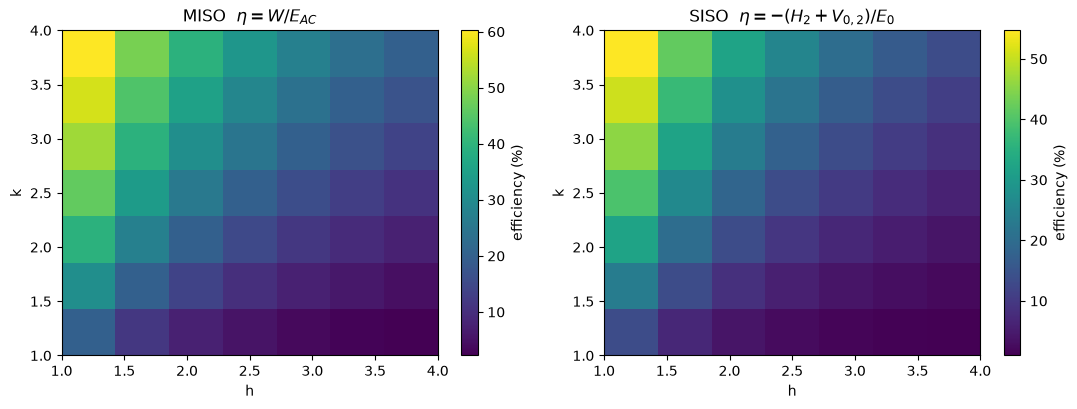

In [8]:
import matplotlib.pyplot as plt

hs = np.arange(1.0, 4.01, 0.5)
ks = np.arange(1.0, 4.01, 0.5)
miso_grid = np.full((len(ks), len(hs)), np.nan)
siso_grid = np.full((len(ks), len(hs)), np.nan)
for i, k in enumerate(ks):
    for j, h in enumerate(hs):
        miso_grid[i, j] = miso(h, k)[2]
        siso_grid[i, j] = siso(h, k)[3]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for a, grid, title in [(ax[0], miso_grid, r"MISO  $\eta=W/E_{AC}$"),
                       (ax[1], siso_grid, r"SISO  $\eta=-(H_2+V_{0,2})/E_0$")]:
    im = a.imshow(grid, origin="lower", aspect="auto",
                  extent=[hs[0], hs[-1], ks[0], ks[-1]], cmap="viridis")
    a.set_xlabel("h"); a.set_ylabel("k"); a.set_title(title)
    fig.colorbar(im, ax=a, label="efficiency (%)")
plt.tight_layout(); plt.show()

## 8. Hardware-ready Qiskit circuits and shot-based readout

We build the actual measurement circuits (state preparation → senders' measurement →
Bob's outcome-conditioned $R_Y$ → basis-change → measurement), run them on the Aer simulator, and
reconstruct the energy components from the shot counts, comparing to the exact values.

In [9]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
sim = AerSimulator(method="statevector")

def best_angles_miso(h, k):
    '''Optimal Bob R_Y(2*theta) angle for each (mu0,mu1) branch (exact grid).'''
    g = ground_state(h, k); H = H_tot(h, k); Cg = cnot01() @ g
    X0, X1, Yb, I8 = op(0, X), op(1, X), op(2, Y), np.eye(8)
    ang = {}
    for mu0 in (1, -1):
        for mu1 in (1, -1):
            psi = ((I8+mu1*X1)/2) @ ((I8+mu0*X0)/2) @ Cg
            psin = psi/np.sqrt(np.vdot(psi, psi).real)
            ths = np.linspace(0, 2*np.pi, 4001)
            e = [np.vdot((np.cos(t/2)*I8-1j*np.sin(t/2)*Yb)@psin,
                         H@((np.cos(t/2)*I8-1j*np.sin(t/2)*Yb)@psin)).real for t in ths]
            ang[(mu0, mu1)] = ths[int(np.argmin(e))]
    return ang

def miso_circuit(h, k, xbasis):
    '''MISO readout circuit. xbasis=True -> V (X-basis), False -> H (Z-basis).'''
    ang = best_angles_miso(h, k)
    qr, cr = QuantumRegister(3, "q"), ClassicalRegister(3, "c")
    qc = QuantumCircuit(qr, cr)
    qc.initialize(ground_state(h, k), [0, 1, 2])
    qc.cx(0, 1)                       # entangle senders
    qc.h(0); qc.h(1)                  # X-basis measurement of senders
    qc.measure(0, 0); qc.measure(1, 1)
    for (mu0, mu1), th in ang.items():
        b0, b1 = (0 if mu0 == 1 else 1), (0 if mu1 == 1 else 1)
        with qc.if_test((cr[0], b0)):
            with qc.if_test((cr[1], b1)):
                qc.ry(th, 2)
    if xbasis:
        qc.h(2)
    qc.measure(2, 2)
    return qc

def corr(counts, i, j, shots):   # <Z_i Z_j> from bitstring counts (c2 c1 c0)
    return sum((1-2*int(b[::-1][i]))*(1-2*int(b[::-1][j]))*n for b, n in counts.items())/shots
def single(counts, i, shots):
    return sum((1-2*int(b[::-1][i]))*n for b, n in counts.items())/shots

SHOTS = 200000
for (h, k) in [(1, 3), (1, 4)]:
    cH, cV = constants(h, k)
    qcV = transpile(miso_circuit(h, k, True), sim)
    qcH = transpile(miso_circuit(h, k, False), sim)
    cV_counts = sim.run(qcV, shots=SHOTS).result().get_counts()
    cH_counts = sim.run(qcH, shots=SHOTS).result().get_counts()
    V02 = cV*1 + k*corr(cV_counts, 0, 2, SHOTS)
    V12 = cV*1 + k*corr(cV_counts, 1, 2, SHOTS)
    H2  = cH*1 + h*single(cH_counts, 2, SHOTS)
    EAC, W_exact, eta_exact = miso(h, k)
    print(f"(h,k)=({h},{k})  sampled:  <V02>={V02:+.3f}  <V12>={V12:+.3f}  <H2>={H2:+.3f}"
          f"   |  exact eta_MISO={eta_exact:.1f}%")

(h,k)=(1,3)  sampled:  <V02>=-0.542  <V12>=-0.541  <H2>=+0.211   |  exact eta_MISO=51.9%


(h,k)=(1,4)  sampled:  <V02>=-0.696  <V12>=-0.708  <H2>=+0.209   |  exact eta_MISO=60.2%


### Citation

If you use this code, please cite the accompanying paper. Code repository:
`https://github.com/C0dE-l3eAkeR/3-Qubit-QET/`.

All exact (statevector) results above are independent of shot noise; the Qiskit section
demonstrates the same quantities reconstructed from finite-shot sampling of the hardware-ready circuits.